In [ ]:

"""
===============
Metrics example
===============
"""

In [231]:
# This example demonstrates different metrics available in Stone Soup and how they
# can be used with the :class:`~.MultiManager` to assess tracking performance. It also
# demonstrates how to use the :class:`~.MetricPlotter` class to easily generate metric plots for
# visualisation.
#
# To generate metrics, we need:
#  - At least one :class:`~.MetricGenerator` - these are used to determine the metric type
#    we want to generate and to compute the metrics themselves.
#  - The :class:`~.MultiManager` metric manager - this is used to hold the metric generator(s)
#    as well as all the ground truth, track, and detection sets we want to generate our
#    metrics from. We will generate our metrics using the :meth:`generate_metrics` method
#    of the :class:`~.MultiManager` class.
#
# In this example, we will create a variety of metric generators for different types of metrics.
# These metrics will be used to assess and compare tracks produced from the same set of ground
# truth paths and detections by the Extended Kalman Filter and the Particle Filter.

In [232]:
# Create metric generators and metric manager
# -------------------------------------------
# In this section we create the metric generators in preparation for generating metrics later.
#
# First, we create some :class:`~.BasicMetrics` generators that will show us the number of tracks,
# the number of targets, and the ratio between them. As with all the metric generators,
# we must give ours a unique name to identify it later, and the keys for our tracks and
# ground truth data (and detections set if relevant). When we generate the metrics, these keys
# will be used to access the data stored in the MultiManager and allow us to specify
# which tracks or truths we want to generate metrics for.
#
# NB: in all metrics that take a track and a truth as input, we can input two tracks
# instead to calculate track to track comparisons. This is relevant in scenarios where a
# second set of tracks is used as a proxy for ground truth. To do this, set the *tracks_key*
# parameter to the tracks set and the *truths_key* parameter to the second tracks set that is
# being used as a ground truth proxy.

from stonesoup.metricgenerator.basicmetrics import BasicMetrics

basic_EKF = BasicMetrics(generator_name='basic_EKF', tracks_key='EKF_tracks', truths_key='truths')
#basic_KF = BasicMetrics(generator_name='basic_KF', tracks_key='KF_tracks', truths_key='truths')

In [233]:
# Next, we create the Optimal SubPattern Assignment (OSPA) metric generator. This metric is
# calculated at each time step to show how far the tracks are from the ground truth paths. It
# returns an overall multi-track to multi-ground-truth missed distance for each time step.
#
# The generator has two additional properties: :math:`p \in [1,\infty]` for outlier sensitivity
# and :math:`c > 1` for cardinality penalty. [#]_

from stonesoup.metricgenerator.ospametric import OSPAMetric, GOSPAMetric

ospa_EKF_truth = OSPAMetric(c=50, p=1, generator_name='OSPA EKF',
                            tracks_key='EKF_tracks', truths_key='truths')
#ospa_KF_truth = OSPAMetric(c=50, p=1, generator_name='OSPA_KF-truth',
                           #tracks_key='KF_tracks', truths_key='truths')
#ospa_EKF_KF = OSPAMetric(c=50, p=1, generator_name='OSPA_EKF-KF',
                        #tracks_key='EKF_tracks', truths_key='KF_tracks')

In [234]:
# Next, we create the Single Integrated Air Picture (SIAP) metric generators. These metrics are
# applicable to tracking in general - not just the air domain. [#]_
#
# The SIAP generators will generate a series of different SIAP metrics that
# provide information about the accuracy of the tracking. They generate different SIAP
# metrics for each time step and calculate averages. SIAP metric averages
# and more explanation into the different plotted metrics are provided later.
#
# The SIAP Metrics require a way to associate tracks to truth, so we'll use a Track to Truth
# associator which uses Euclidean distance measure by default.

from stonesoup.metricgenerator.tracktotruthmetrics import SIAPMetrics
from stonesoup.measures import Euclidean

siap_EKF_truth = SIAPMetrics(position_measure=Euclidean((0, 2)),
                             velocity_measure=Euclidean((1, 3)),
                             generator_name='SIAP EKF',
                             tracks_key='EKF_tracks',
                             truths_key='truths'
                             )

'''
siap_KF_truth = SIAPMetrics(position_measure=Euclidean((0, 2)),
                            velocity_measure=Euclidean((1, 3)),
                            generator_name='SIAP_KF-truth',
                            tracks_key='KF_tracks',
                            truths_key='truths'
                            )
'''

from stonesoup.dataassociator.tracktotrack import TrackToTruth

associator = TrackToTruth(association_threshold=13.82)

In [235]:
# Next, we create metric generators for the :class:`~.SumofCovarianceNormsMetric`. They will
# calculate the sum of the covariance matrix norms of each track state at each time step. These
# metrics produced will indicate how uncertain the tracks we have produced are. Higher sum of
# covariance norms means higher uncertainty.

from stonesoup.metricgenerator.uncertaintymetric import SumofCovarianceNormsMetric

sum_cov_norms_EKF = SumofCovarianceNormsMetric(tracks_key='EKF_tracks',
                                               generator_name='Uncertainty EKF')
#sum_cov_norms_KF = SumofCovarianceNormsMetric(tracks_key='KF_tracks',
 #                                             generator_name='sum_cov_norms_KF')

In [ ]:
# Finally, we create two plot generators - one for each of the two different trackers we are
# using. These will take in the tracks, ground truths, and detections that we generate and plot
# them in 2 dimensions.

from stonesoup.metricgenerator.plotter import TwoDPlotter

plot_generator_EKF = TwoDPlotter([0, 2], [0, 2], [0, 2], uncertainty=True, tracks_key='EKF_tracks',
                                 truths_key='truths', detections_key='detections',
                                 generator_name='EKF_plot')
#plot_generator_KF = TwoDPlotter([0, 2], [0, 2], [0, 2], uncertainty=True, tracks_key='KF_tracks',
 #                               truths_key='truths', detections_key='detections',
 #                               generator_name='KF_plot')

gospa_EKF_truth = GOSPAMetric(
    p=1,
    c=50,
    switching_penalty=0.0,
    measure=Euclidean(),
    tracks_key='EKF_tracks',
    truths_key='truths',
    generator_name='GOSPA_EKF_vs_Truth'
)
'''
gospa_KF_truth = GOSPAMetric(
    p=1,
    c=50,
    switching_penalty=0.0,
    measure=Euclidean(),
    generator_name='GOSPA_KF_vs_Truth'
)
'''

In [237]:
# Add our metric generators to the :class:`~.MultiManager`:

from stonesoup.metricgenerator.manager import MultiManager

metric_manager = MultiManager([basic_EKF,
                               gospa_EKF_truth,
                               ospa_EKF_truth,
                               siap_EKF_truth,
                               sum_cov_norms_EKF,
                               plot_generator_EKF,
                               ], associator) 



In [ ]:
import numpy as np
from datetime import datetime, timedelta

from stonesoup.types.array     import StateVector, CovarianceMatrix
from stonesoup.types.state     import GaussianState
from stonesoup.types.groundtruth import GroundTruthPath
from stonesoup.simulator.platform import PlatformDetectionSimulator
from stonesoup.platform.base   import FixedPlatform
from stonesoup.sensor.radar.radar import RadarElevationBearingRange
from stonesoup.models.clutter  import ClutterModel

# 1) Build your fixed S1 paths
def build_s1_paths(start_time, step_interval, num_steps=300):
    wps = [
        [(-750,  60), (-750, -60)],
        [(   -250,   5), (   -250,  -5)],
        [( 250,   5), ( 250,  -5)],
        [( 750,  60), ( 750, -60)],
    ]
    seg_len = num_steps // 3  # 100 steps each segment
    paths = []

    for track_id in (0, 1):
        states = []
        pos = np.array(wps[0][track_id], float)

        for idx in range(len(wps) - 1):
            x1, y1 = wps[idx][track_id]
            x2, y2 = wps[idx + 1][track_id]
            vel = (np.array([x2, y2], float) - np.array([x1, y1], float)) / seg_len

            for _ in range(seg_len):
                arr = np.array([pos[0], vel[0], pos[1], vel[1]],
                               float).reshape(4, 1)
                vec = StateVector(arr)
                cov = CovarianceMatrix(np.zeros((4, 4)))
                timestamp = start_time + (len(states) + 1) * step_interval
                states.append(GaussianState(vec, cov, timestamp=timestamp))
                pos += vel

        # note: id must be a string
        paths.append(GroundTruthPath(states, id=str(track_id)))
    return paths

start_time    = datetime.now()
dt            = timedelta(seconds=1)
gt_paths      = build_s1_paths(start_time, dt)


# 2) Duck-type reader for PlatformDetectionSimulator
class SimpleGT:
    def __init__(self, paths):
        # assume all paths have same length+timestamps
        self.paths = paths

    def __iter__(self):
        return self.groundtruth_paths_gen()

    def groundtruth_paths_gen(self):
        length = len(self.paths[0].states)
        for step in range(length):
            t = self.paths[0].states[step].timestamp
            # yield the partial paths up to this scan
            yield t, {
                GroundTruthPath(
                    path.states[: step + 1], id=path.id
                )
                for path in self.paths
            }

gt_reader = SimpleGT(gt_paths)

import numpy as np
import matplotlib.pyplot as plt

# Assuming you already have:
#   gt_paths = build_s1_paths(start_time, dt)

# 1) Extract x/y for each track
plt.figure(figsize=(8, 6))
for path in gt_paths:
    xs = [state.state_vector[0, 0] for state in path.states]
    ys = [state.state_vector[2, 0] for state in path.states]
    plt.plot(xs, ys, linewidth=2, label=f"Track {path.id}")

# 2) Aesthetics: grid, labels, legend
plt.title("Ground Truth Trajectories (S1 Scenario)", fontsize=20)
plt.xlabel("x-coordinate [m]", fontsize=20)
plt.ylabel("y-coordinate [m]", fontsize=20)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.legend(fontsize=15, loc="best", frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from datetime import datetime
from stonesoup.types.array     import StateVector, CovarianceMatrix
from stonesoup.types.state     import State
from stonesoup.platform.base   import FixedPlatform
from stonesoup.sensor.radar    import RadarBearingRange
from stonesoup.models.measurement.linear import LinearGaussian
from stonesoup.models.clutter  import ClutterModel
from stonesoup.simulator.platform import PlatformDetectionSimulator

# 1) Stationary platform at origin
start_time    = datetime.now()
plat_vec      = StateVector([0.0, 0.0]).reshape(2, 1)
plat_state    = State(plat_vec, start_time)
platform      = FixedPlatform(plat_state, position_mapping=(0, 1))

# 2) Measurement model
pd      = 0.5      
sigma   = 10.0      
meas_model = LinearGaussian(
    ndim_state=4,            # Using statevector - [x, vx, y, vy]
    mapping=(0, 2),          
    noise_covar=CovarianceMatrix(
        np.diag([sigma**2, sigma**2])
    )
)

# 3) Clutter
mu_c = 10
roi  = ((-750, 750), (-750, 750))
clutter = ClutterModel(
    clutter_rate=mu_c,
    distribution=np.random.default_rng().uniform,
    dist_params=roi
)

# 4) Sensor Model
sensor = RadarBearingRange(
    ndim_state=4,
    position_mapping=(0, 2),     
    noise_covar=meas_model.noise_covar,
    clutter_model=clutter
)

# Override for correct detection probability
sensor.detection_probability = pd
sensor._measurement_model     = meas_model
platform.add_sensor(sensor)

# 5) Collect the detections
detector = PlatformDetectionSimulator(
    groundtruth=gt_reader,     
    platforms=[platform]
)

# Sanity‐check: print how many detections you get each scan
for time, detections in detector:
    print(f"{time:%H:%M:%S} → {len(detections)} measurements")



In [240]:
detections = set()
truths = set()

for time, detects in detector:
    detections |= detects
    truths |= set(gt_paths)

from itertools import tee

det_ekf, det_kf = tee(detector, 2)


In [241]:
from itertools import tee
from datetime import timedelta

import numpy as np
from stonesoup.types.state           import GaussianState
from stonesoup.types.array           import StateVector, CovarianceMatrix
from stonesoup.tracker.simple        import MultiTargetMixtureTracker
from stonesoup.initiator.simple      import MultiMeasurementInitiator
from stonesoup.deleter.time          import UpdateTimeDeleter
from stonesoup.hypothesiser.distance import DistanceHypothesiser
from stonesoup.dataassociator.neighbour import GNNWith2DAssignment
from stonesoup.dataassociator.probability import JPDAwithLBP as JPDA
from stonesoup.hypothesiser.probability   import PDAHypothesiser
from stonesoup.models.transition.linear   import CombinedLinearGaussianTransitionModel, ConstantVelocity
from stonesoup.predictor.kalman            import KalmanPredictor, ExtendedKalmanPredictor
from stonesoup.updater.kalman              import KalmanUpdater, ExtendedKalmanUpdater
from stonesoup.models.measurement.linear   import LinearGaussian
from stonesoup.measures import Mahalanobis

# 0) Split the detection stream
det_ekf, det_kf = tee(detector, 2)

# 1) Shared models
process_noise     = 0.1
transition_model  = CombinedLinearGaussianTransitionModel([
    ConstantVelocity(process_noise),
    ConstantVelocity(process_noise)
])

sigma_v   = 10.0
meas_model = LinearGaussian(
    ndim_state  = 4,
    mapping     = (0, 2),
    noise_covar = CovarianceMatrix(np.diag([sigma_v**2, sigma_v**2]))
)

mu_c            = 10
roi_area        = 1500 * 1500
clutter_density = mu_c / roi_area
p_d             = 0.5

deleter = UpdateTimeDeleter(timedelta(seconds=1), delete_last_pred=True)

prior = GaussianState(
    StateVector([[-750], [10], [150], [0]]),
    np.diag([100, 10, 100, 10])
)


# -------------------------------------------------------------------
# EKF + JPDAF (Mixture Tracker)
# -------------------------------------------------------------------
predictor_EKF = ExtendedKalmanPredictor(transition_model)
updater_EKF   = ExtendedKalmanUpdater(sensor)

pda_hyp_ekf = PDAHypothesiser(
    predictor               = predictor_EKF,
    updater                 = updater_EKF,
    clutter_spatial_density = clutter_density,
    prob_detect             = p_d
)
da_jpda_ekf = JPDA(hypothesiser=pda_hyp_ekf)

# Initiator still needs a single-hypothesis associator (hard‐assignment)
init_hyp_ekf  = DistanceHypothesiser(predictor_EKF, updater_EKF,
                                     measure=Mahalanobis(),
                                     missed_distance=13.82)
init_assoc_ekf = GNNWith2DAssignment(init_hyp_ekf)

initiator_jpda_ekf = MultiMeasurementInitiator(
    prior_state      = prior,
    measurement_model= meas_model,
    deleter          = deleter,
    data_associator  = init_assoc_ekf,
    updater          = updater_EKF,
    min_points       = 2
)

tracker_EKF_JPDAF = MultiTargetMixtureTracker(
    initiator       = initiator_jpda_ekf,
    deleter         = deleter,
    detector        = det_ekf,
    data_associator = da_jpda_ekf,
    updater         = updater_EKF
)

"""
# -------------------------------------------------------------------
# KF + JPDAF (Mixture Tracker)
# -------------------------------------------------------------------
predictor_KF = KalmanPredictor(transition_model)
updater_KF   = KalmanUpdater(sensor)

pda_hyp_kf  = PDAHypothesiser(
    predictor               = predictor_KF,
    updater                 = updater_KF,
    clutter_spatial_density = clutter_density,
    prob_detect             = p_d
)
da_jpda_kf = JPDA(hypothesiser=pda_hyp_kf)

init_hyp_kf  = DistanceHypothesiser(predictor_KF, updater_KF,
                                    measure=Mahalanobis(),
                                    missed_distance=13.82)
init_assoc_kf = GNNWith2DAssignment(init_hyp_kf)

initiator_jpda_kf = MultiMeasurementInitiator(
    prior_state      = prior,
    measurement_model= meas_model,
    deleter          = deleter,
    data_associator  = init_assoc_kf,
    updater          = updater_KF,
    min_points       = 2
)

tracker_KF_JPDAF = MultiTargetMixtureTracker(
    initiator       = initiator_jpda_kf,
    deleter         = deleter,
    detector        = det_kf,
    data_associator = da_jpda_kf,
    updater         = updater_KF
)
"""
# -------------------------------------------------------------------
# Run and collect both sets of tracks
# -------------------------------------------------------------------
for step, (time, tracks) in enumerate(tracker_EKF_JPDAF, 1):
    metric_manager.add_data({'EKF_tracks': tracks}, overwrite=False)

#for step, (time, tracks) in enumerate(tracker_KF_JPDAF, 1):
#    metric_manager.add_data({'KF_JPDAF_tracks': tracks}, overwrite=False)


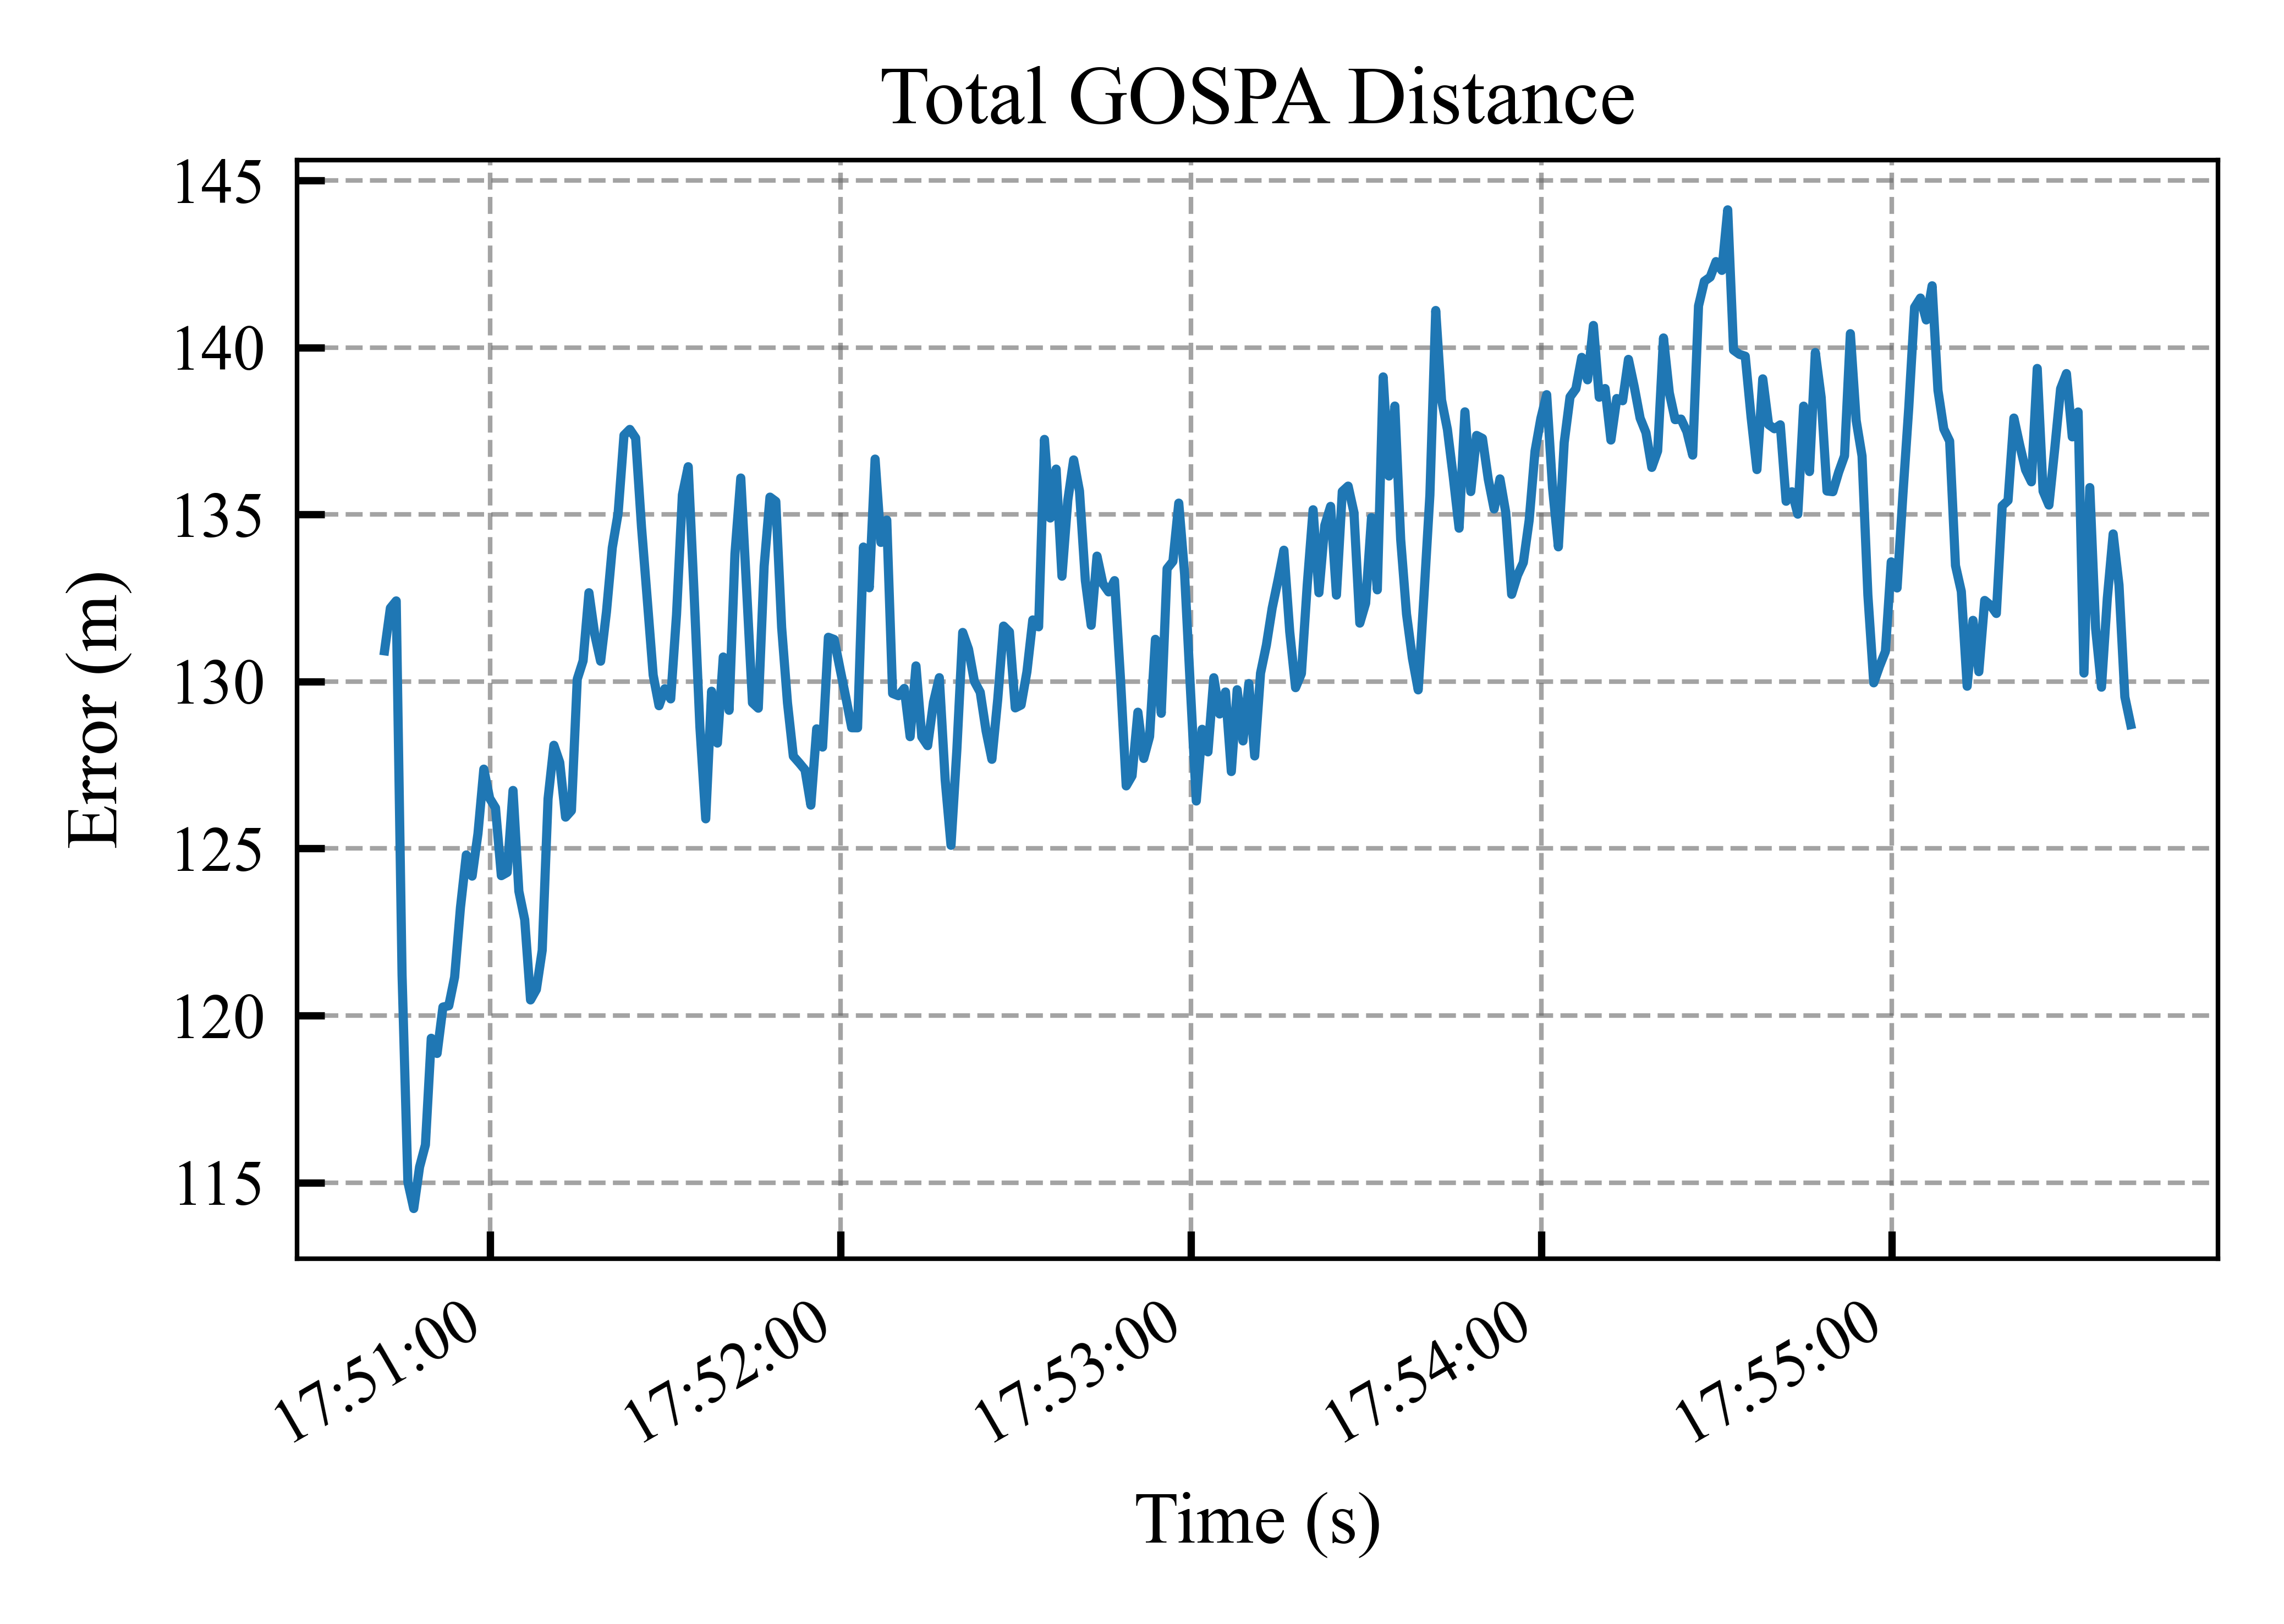

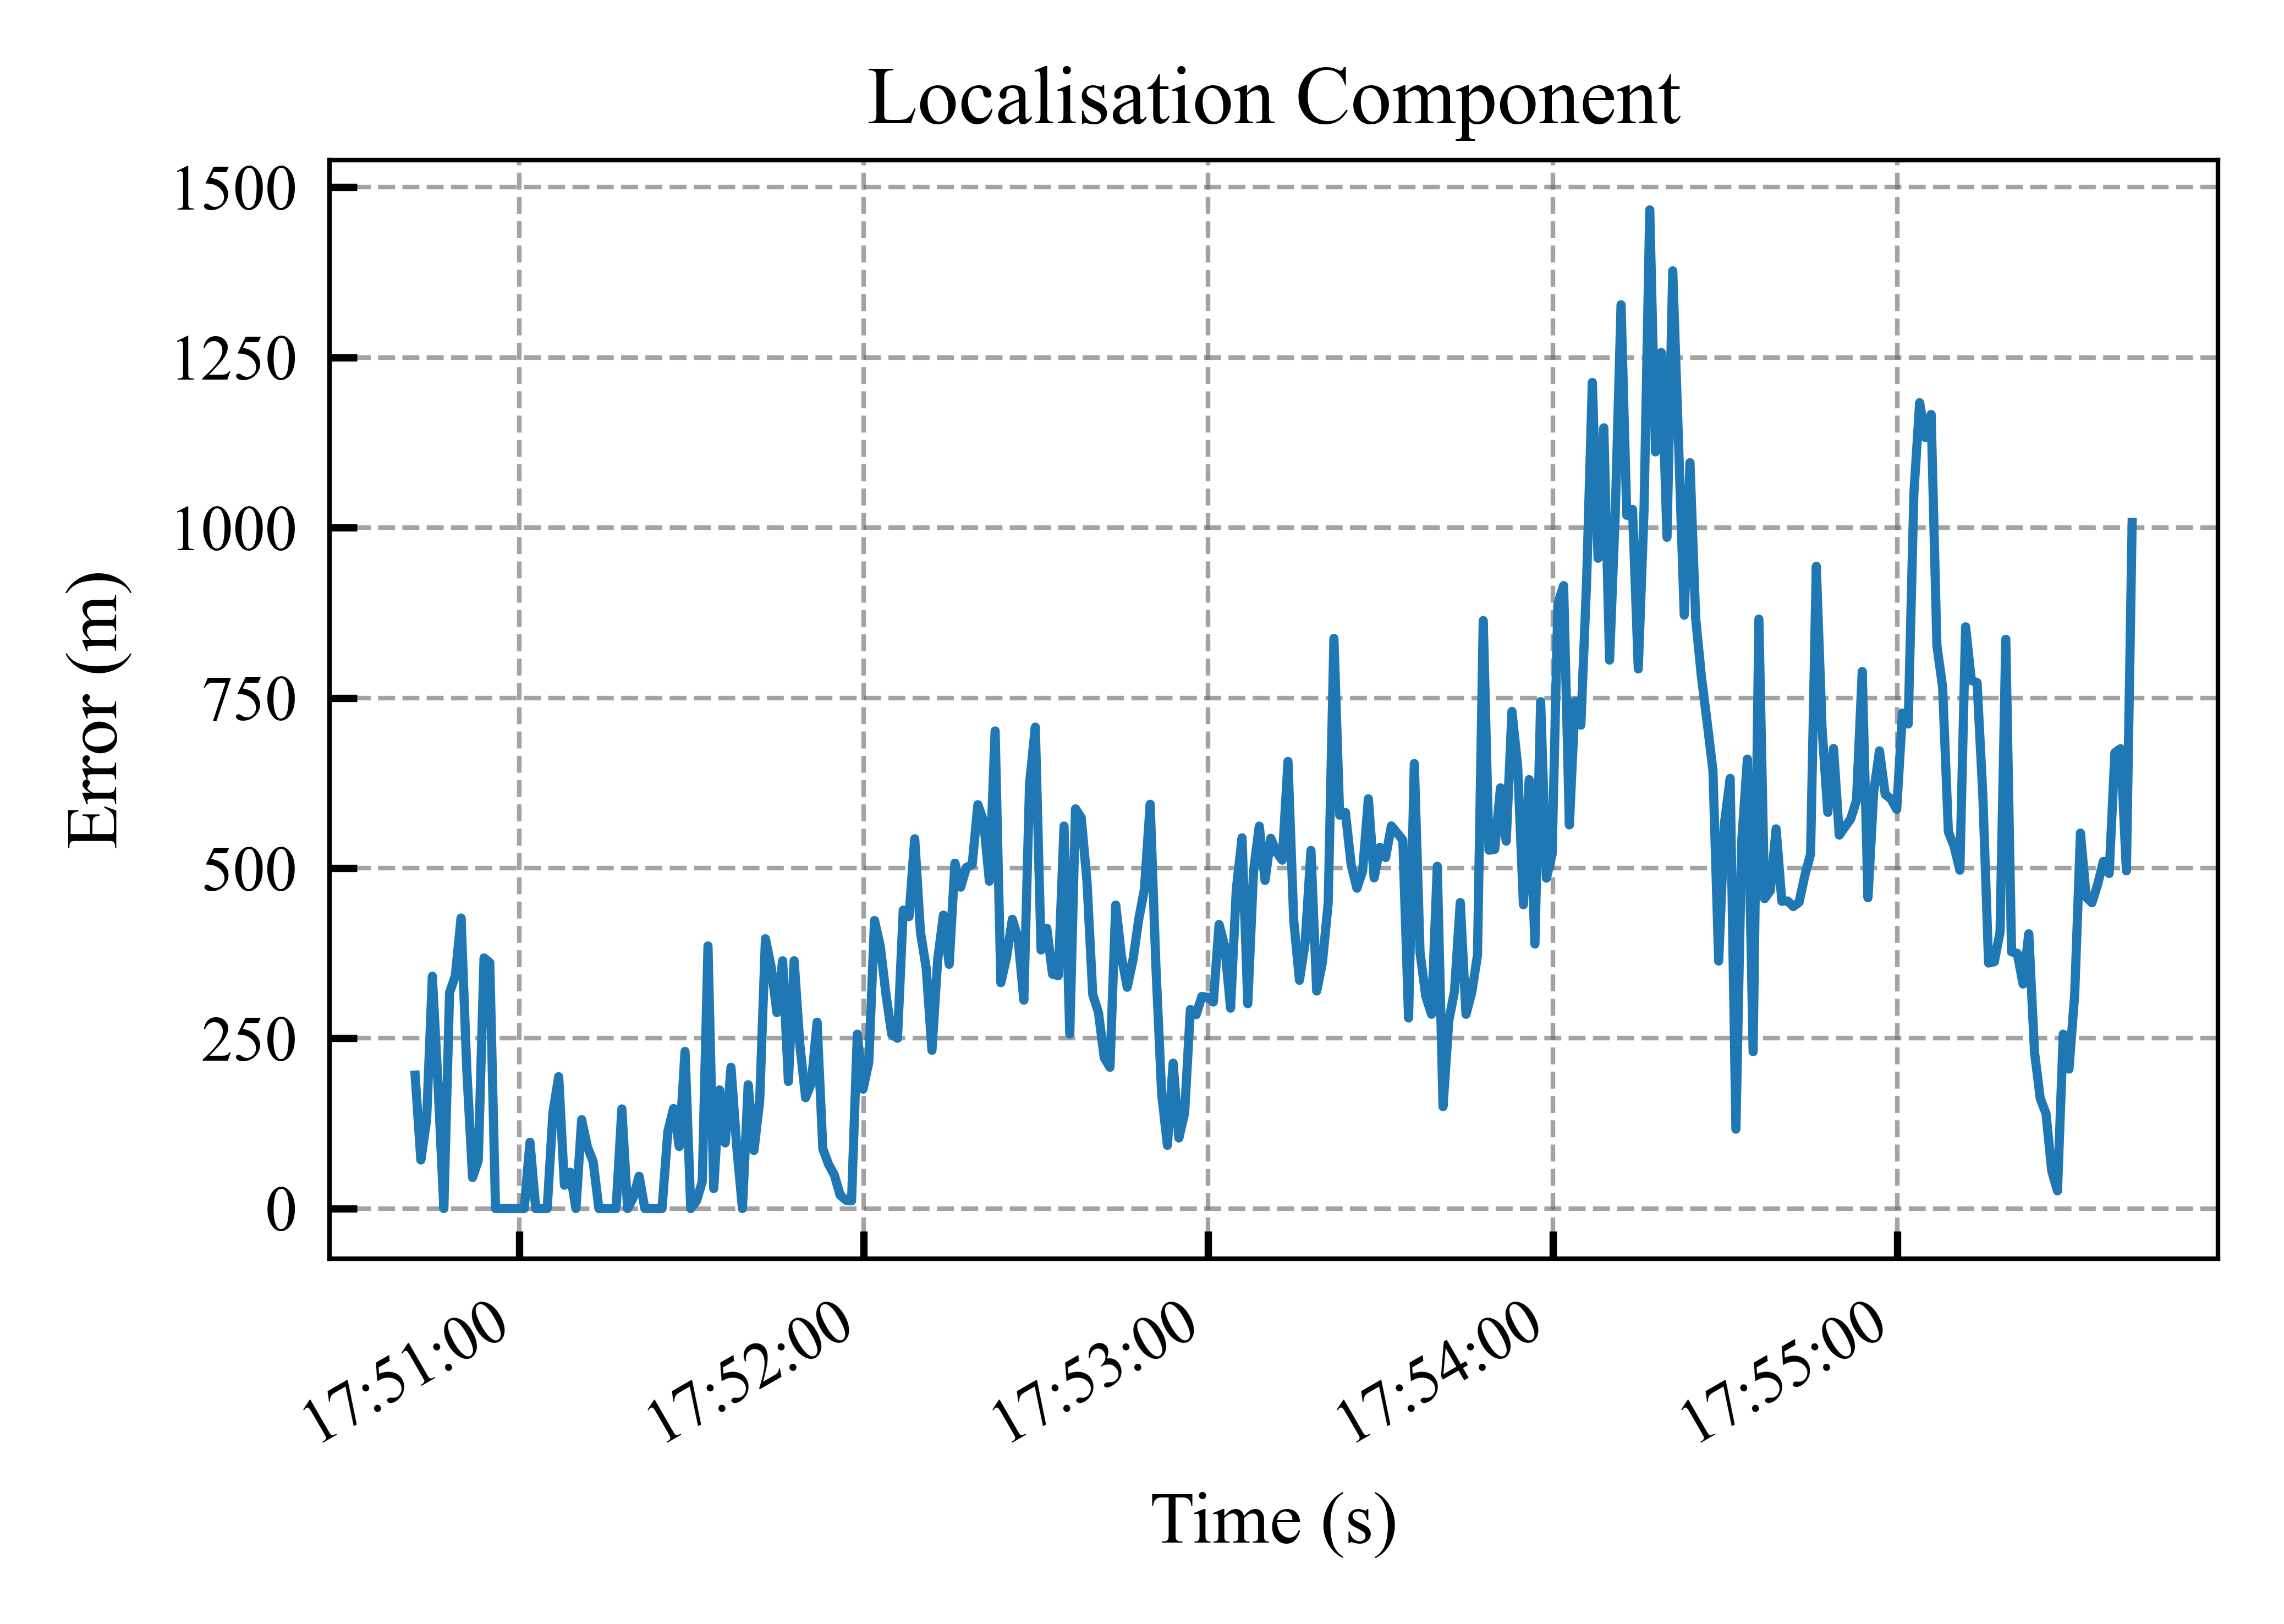

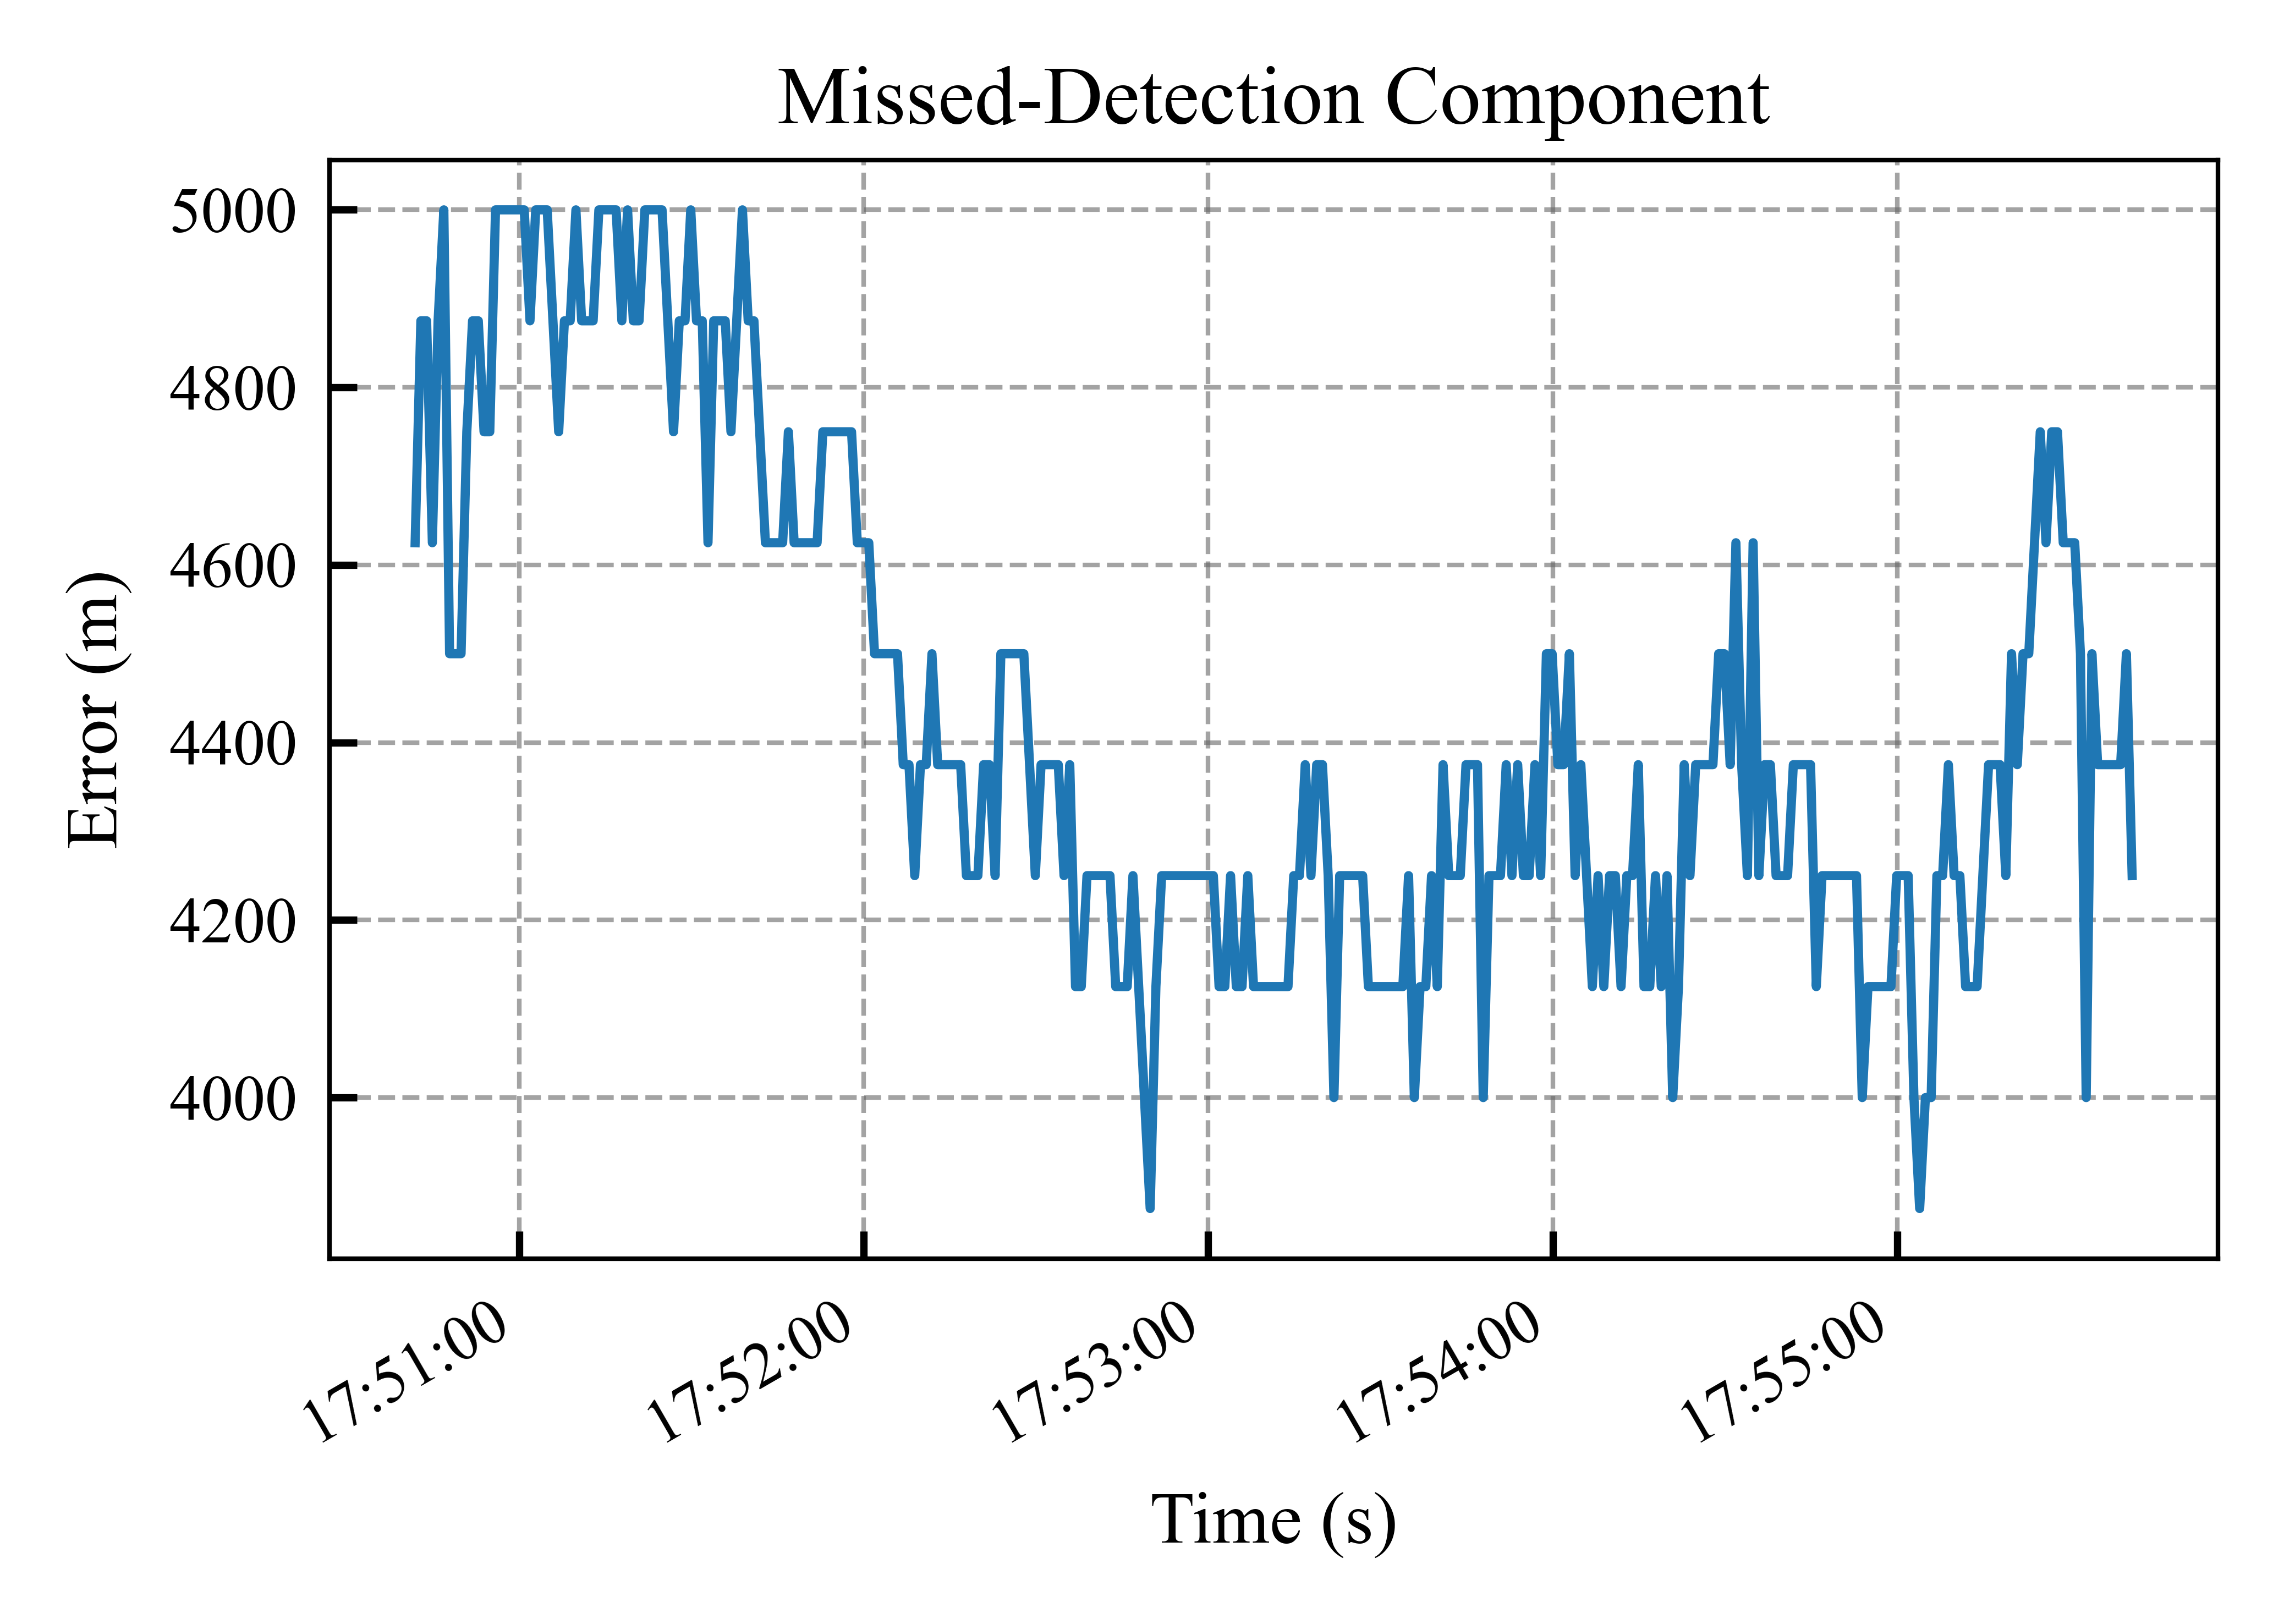

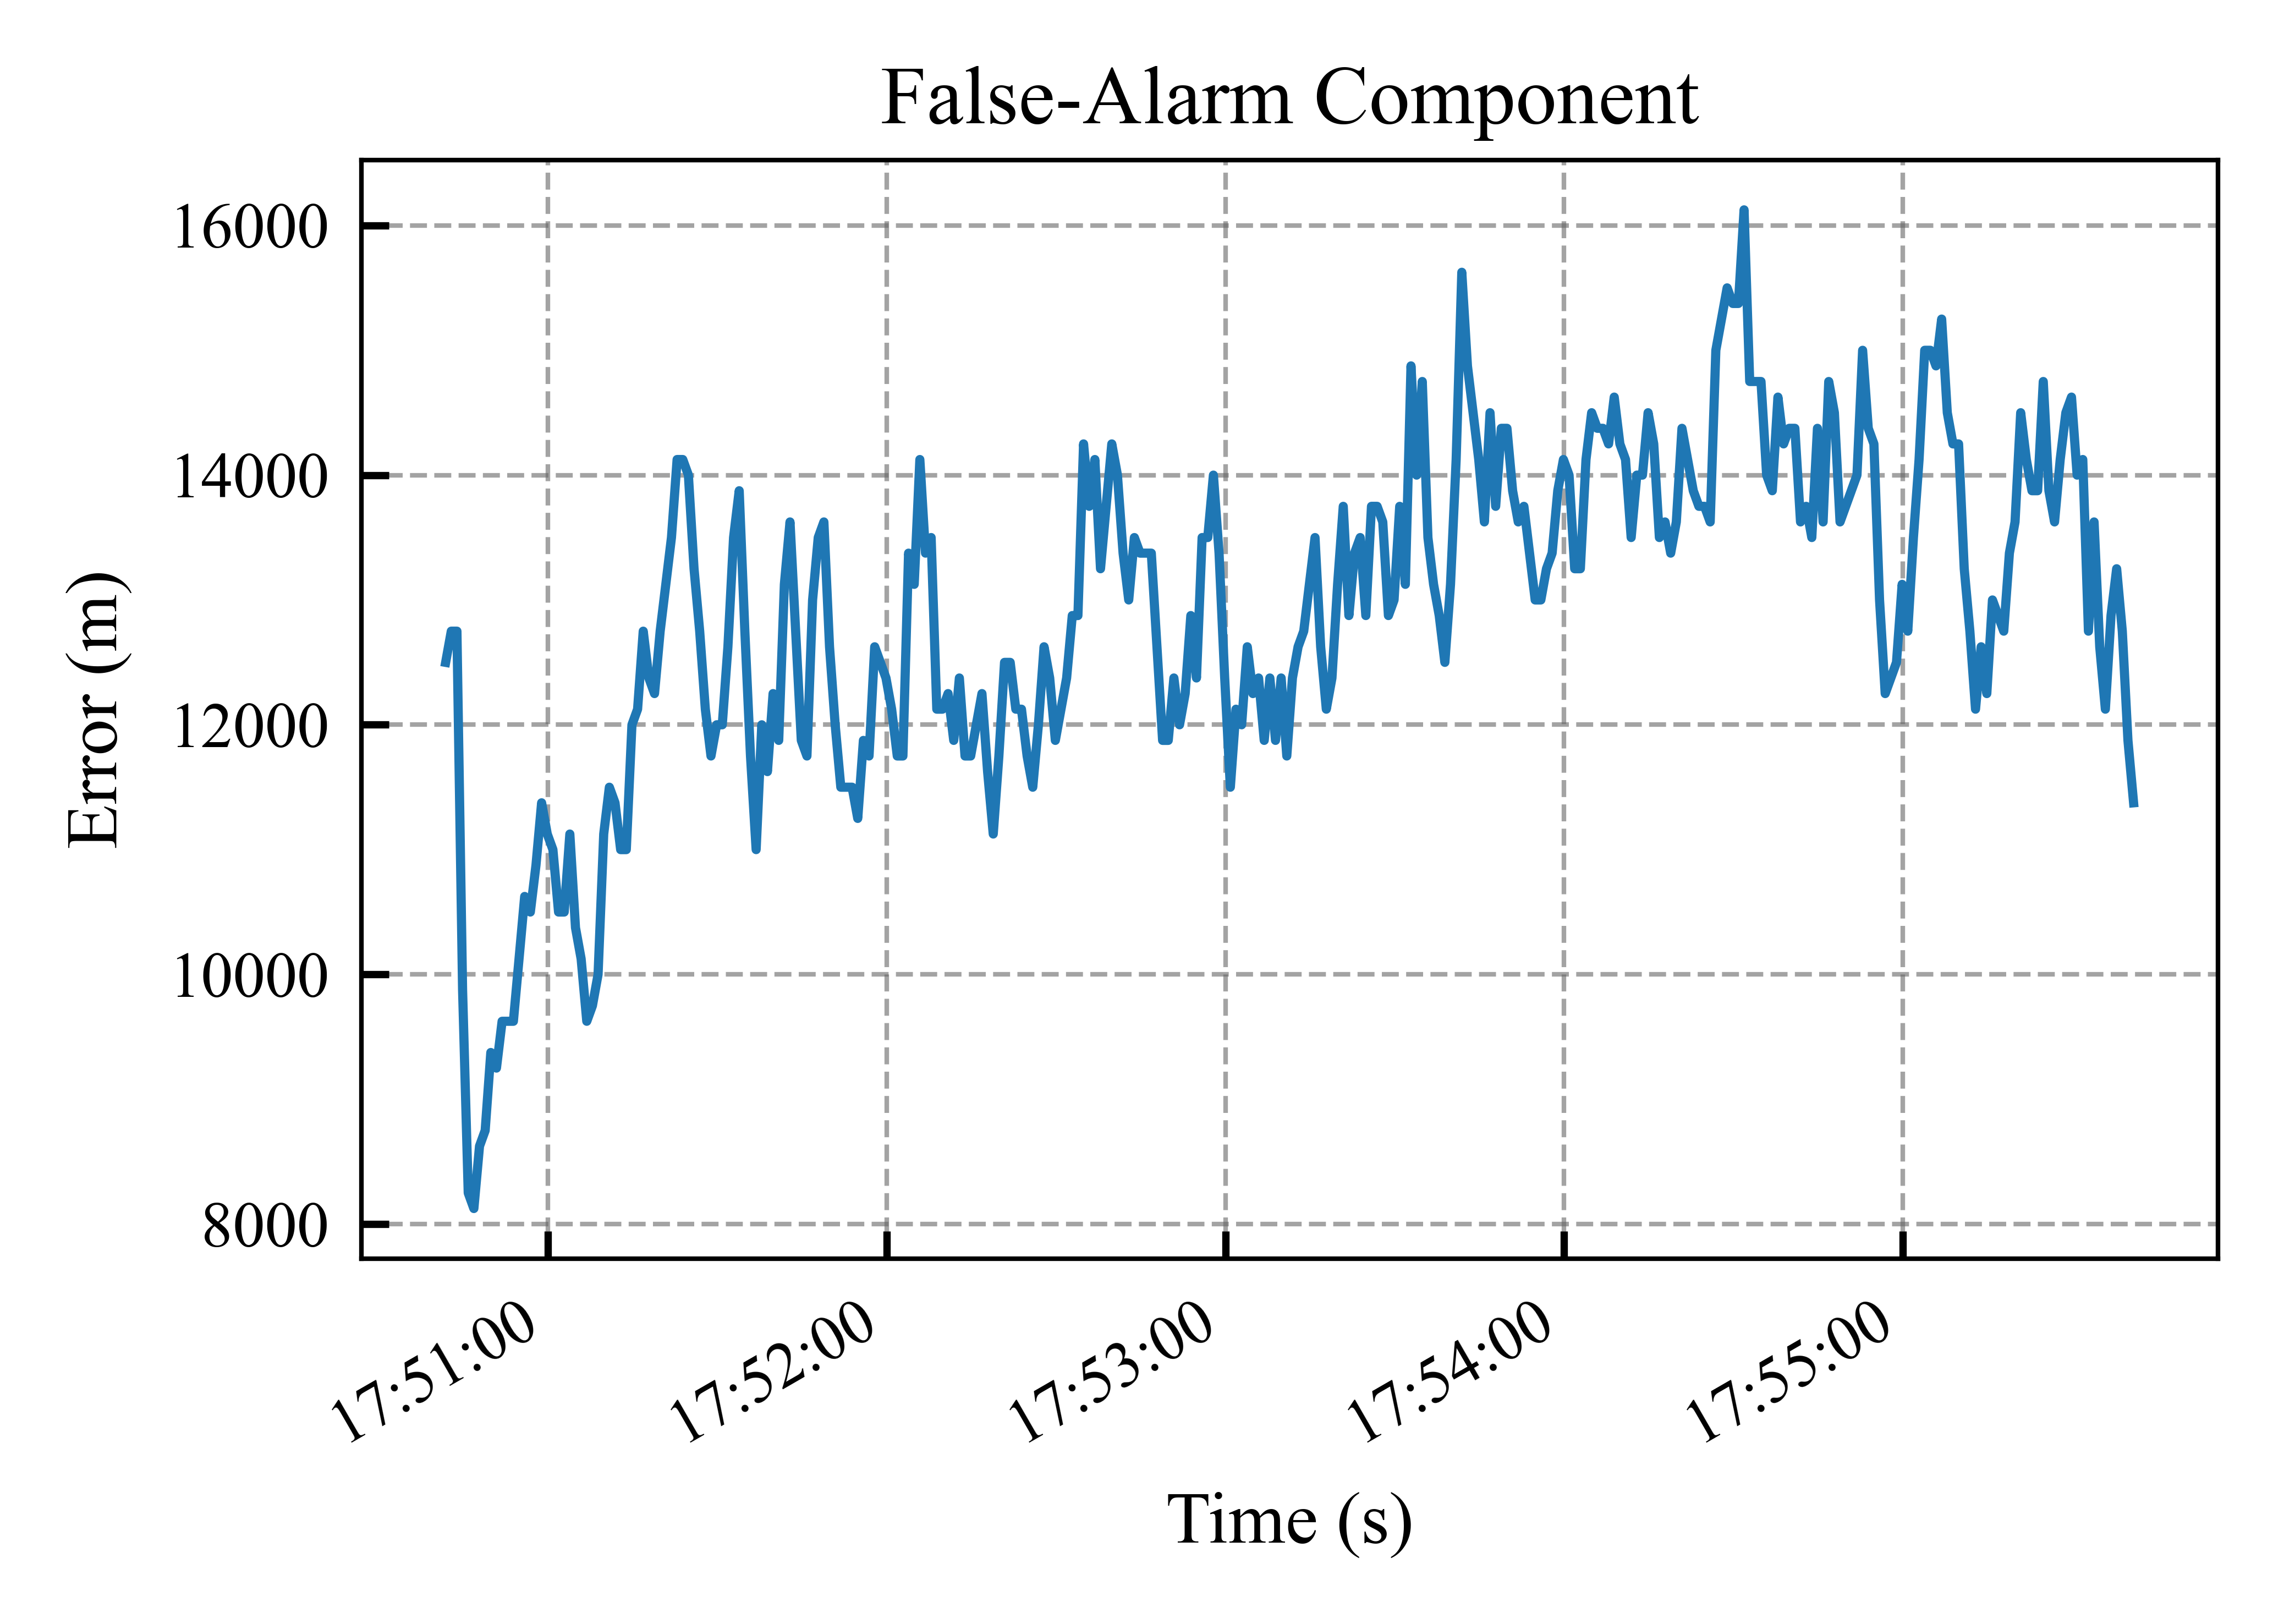

In [17]:
# Independent Generator for GOSPA Metrics and Sub-Components
# -----------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Stone Soup imports
from stonesoup.types.array        import StateVector, CovarianceMatrix
from stonesoup.types.state        import GaussianState
from stonesoup.types.groundtruth  import GroundTruthPath
from stonesoup.platform.base      import FixedPlatform
from stonesoup.simulator.platform import PlatformDetectionSimulator
from stonesoup.sensor.radar.radar import RadarBearingRange
from stonesoup.models.clutter     import ClutterModel
from stonesoup.models.measurement.linear import LinearGaussian

from stonesoup.tracker.simple        import MultiTargetMixtureTracker
from stonesoup.initiator.simple      import MultiMeasurementInitiator
from stonesoup.hypothesiser.distance import DistanceHypothesiser
from stonesoup.deleter.time          import UpdateTimeDeleter
from stonesoup.dataassociator.probability import JPDAwithLBP as JPDA 
from stonesoup.hypothesiser.probability   import PDAHypothesiser
from stonesoup.models.transition.linear   import CombinedLinearGaussianTransitionModel, ConstantVelocity
from stonesoup.predictor.kalman            import ExtendedKalmanPredictor
from stonesoup.updater.kalman              import ExtendedKalmanUpdater
from stonesoup.metricgenerator.ospametric import GOSPAMetric
from stonesoup.metricgenerator.manager    import MultiManager
from stonesoup.measures import Mahalanobis
from stonesoup.measures import Euclidean
from stonesoup.dataassociator.neighbour import GNNWith2DAssignment

# 0) basic class
class SimpleGT:
    def __init__(self, paths):
        # assume all paths have same length+timestamps
        self.paths = paths

    def __iter__(self):
        return self.groundtruth_paths_gen()

    def groundtruth_paths_gen(self):
        length = len(self.paths[0].states)
        for step in range(length):
            t = self.paths[0].states[step].timestamp
            # yield the partial paths up to this scan
            yield t, {
                GroundTruthPath(
                    path.states[: step + 1], id=path.id
                )
                for path in self.paths
            }

# 1) Your S1 ground-truth generator
def build_s1_paths(start_time, dt, num_steps=300):
    """
    Returns a list of GroundTruthPath, one per target, each with num_steps states.
    """
    waypoints = [
       [(-750,  60), (-750, -60)],
       [(-250,   5), (-250,  -5)],
       [( 250,  -5), ( 250,   5)],
       [( 750, -60), ( 750,   60)],
    ]
    paths = []
    for tid, (p0, p1) in enumerate(waypoints):
        states = []
        for k in range(num_steps):
            frac = k/(num_steps-1)
            x = p0[0] + frac*(p1[0]-p0[0])
            y = p0[1] + frac*(p1[1]-p0[1])
            vec = StateVector([x, 0.0, y, 0.0]).reshape(4,1)
            cov = CovarianceMatrix(np.diag([100,1,100,1]))
            # note: GaussianState expects (state_vector, timestamp, covar)
            timestamp = start_time + k*dt
            states.append(GaussianState(vec, cov, timestamp=timestamp))
        paths.append(GroundTruthPath(states, id=tid))
    return paths

# 2) Monte-Carlo + GOSPA loop

# a) initial time values and parameters
num_runs  = 10
num_steps = 300
all_dist  = np.empty((num_runs, num_steps))
all_loc   = np.empty_like(all_dist)
all_miss  = np.empty_like(all_dist)
all_false = np.empty_like(all_dist)
start_time=datetime.now()

# b) Platform for Sensor
platform = FixedPlatform(
        GaussianState(StateVector([0,0,0,0]).reshape(4,1),
                    CovarianceMatrix(np.eye(4)), timestamp=start_time),
        position_mapping=(0,2)
    )

# c) Transition Model and EKF Predictor
process_noise = 0.1
transition_model = CombinedLinearGaussianTransitionModel([
        ConstantVelocity(process_noise),
        ConstantVelocity(process_noise)
    ])
predictor_EKF = ExtendedKalmanPredictor(transition_model)

# d) Measurement model
sigma   = 10.0      
meas_model = LinearGaussian(
    ndim_state=4,            # Using statevector - [x, vx, y, vy]
    mapping=(0, 2),          
    noise_covar=CovarianceMatrix(
        np.diag([sigma**2, sigma**2])
    )
)

# e) Sensor Model and Clutter
mu_c = 10
roi  = ((-750, 750), (-750, 750))
clutter = ClutterModel(
    clutter_rate=mu_c,
    distribution=np.random.default_rng().uniform,
    dist_params=roi
)
roi_area        = 1500 * 1500
clutter_density = mu_c / roi_area
p_d             = 0.5

sensor = RadarBearingRange(
        ndim_state=4,
        position_mapping=(0, 2),     
        noise_covar=meas_model.noise_covar,
        clutter_model=clutter
    )

# f) Adding sensor to Platform and EKF Updater
sensor._measurement_model   = meas_model
sensor.detection_probability = pd
platform.add_sensor(sensor)
updater_EKF   = ExtendedKalmanUpdater(sensor)

# g) PDA Hypothesiser
pda_hyp_ekf = PDAHypothesiser(
        predictor               = predictor_EKF,
        updater                 = updater_EKF,
        clutter_spatial_density = clutter_density,
        prob_detect             = p_d
)

# h) JPDA Object
da_jpda_ekf = JPDA(hypothesiser=pda_hyp_ekf)

# i) Initiators
init_hyp_ekf  = DistanceHypothesiser(predictor_EKF, updater_EKF,
                                     measure=Mahalanobis(),
                                     missed_distance=13.82)
init_assoc_ekf = GNNWith2DAssignment(init_hyp_ekf)

prior = GaussianState(
    StateVector([[-750], [10], [150], [0]]),
    0.1*np.array([[1/3, 0, 1/2, 0],[0, 1/3, 0, 1/2],[1/2, 0, 1, 0],[0, 1/2, 0, 1]])
)

deleter = UpdateTimeDeleter(timedelta(seconds=1), delete_last_pred=True)

initiator_jpda_ekf = MultiMeasurementInitiator(
        prior_state      = prior,
        measurement_model= meas_model,
        deleter          = deleter,
        data_associator  = init_assoc_ekf,
        updater          = updater_EKF,
        min_points       = 2
    )


# j) Monte Carlo Loop
for run in range(num_runs):
    # a) Ground Truth
    start_time = datetime.now()
    dt         = timedelta(seconds=1)
    gt_paths   = build_s1_paths(start_time, dt, num_steps=300)
    
    # b) Detector
    gt_reader = SimpleGT(gt_paths)
    detector = PlatformDetectionSimulator(
        groundtruth=gt_reader,
        platforms=[platform],
    )
    detector_iter = iter(detector)

    # c) Tracker
    tracker_EKF_JPDAF = MultiTargetMixtureTracker(
        initiator       = initiator_jpda_ekf,
        deleter         = deleter,
        detector        = detector,
        data_associator = da_jpda_ekf,
        updater         = updater_EKF
    )

    tracker_EKF_JPDAF_iter = iter(tracker_EKF_JPDAF)

    # d) GOSPA Metric 
    gospa_gen      = GOSPAMetric(
        p=1, c=50,
        switching_penalty=0.0,
        measure=Euclidean(),
        tracks_key='EKF_tracks',
        truths_key='truths',
        generator_name='GOSPA_EKF_vs_Truth'
    )

    # e) Metric Manager
    metric_manager = MultiManager([gospa_gen])
    for k in range(300):
        time, trks = next(tracker_EKF_JPDAF_iter)
        truths     = [path.states[k] for path in gt_paths]
        metric_manager.add_data({
            'truths': truths,
            'EKF_tracks': trks
        }, overwrite=False)

    # f) Final Processing
    metrics = metric_manager.generate_metrics()
    gm = metrics['GOSPA_EKF_vs_Truth']['GOSPA Metrics'].value
    full_dist  = np.array([mv.value['distance']     for mv in gm])
    full_loc   = np.array([mv.value['localisation'] for mv in gm])
    full_miss  = np.array([mv.value['missed']       for mv in gm])
    full_false = np.array([mv.value['false']        for mv in gm])

    dist_row  = full_dist [:num_steps]
    loc_row   = full_loc  [:num_steps]
    miss_row  = full_miss [:num_steps]
    false_row = full_false[:num_steps]

    all_dist [run, :] = dist_row
    all_loc  [run, :] = loc_row
    all_miss [run, :] = miss_row
    all_false[run, :] = false_row

# End Loop

# 3) Stack and average
dist_arr   = np.vstack(all_dist)    # shape (1000,300)
loc_arr    = np.vstack(all_loc)
miss_arr   = np.vstack(all_miss)
false_arr  = np.vstack(all_false)

mean_dist  = dist_arr.mean(axis=0)
mean_loc   = loc_arr.mean(axis=0)
mean_miss  = miss_arr.mean(axis=0)
mean_false = false_arr.mean(axis=0)

# Grab the timestamps once (same for every run)
times = [mv.timestamp for mv in gm]

# 4) Plot each component in its own IEEE-style panel
import matplotlib.dates as mdates
plt.rcParams.update({
    'font.family':    'serif',
    'font.serif':     ['Times New Roman','Times'],
    'font.size':      8,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize':7,
    'ytick.labelsize': 7,
    'axes.linewidth':0.5,
    'lines.linewidth':0.5,
    'xtick.direction':'in',
    'ytick.direction':'in',
    'xtick.major.size':3,
    'ytick.major.size':3,
    'grid.linestyle':'--',
    'grid.linewidth':0.5,
    'grid.color':'#666666',
    'figure.dpi':1200,
})

components = {
    'Total GOSPA Distance':       mean_dist,
    'Localisation Component':     mean_loc,
    'Missed-Detection Component': mean_miss,
    'False-Alarm Component':      mean_false,
}

for title, vals in components.items():
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    ax.plot(times, vals, linewidth=1)
    ax.set_title(title, pad=4)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Error (m)')
    ax.grid(True, alpha=0.6)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    fig.autofmt_xdate(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


for step, (time, tracks) in enumerate(tracker_EKF_JPDAF, 1):
    metric_manager.add_data({'EKF_tracks': tracks}, overwrite=False)
    
for _, (_, ekf_trks) in enumerate(tracker_EKF_JPDAF, 1):
    metric_manager.add_data({'EKF_tracks': ekf_trks,
                             "tracks":     ekf_trks}, overwrite=False)

metric_manager.add_data({
    'truths':     truths,
    'detections': detections
}, overwrite=False)

metrics = metric_manager.generate_metrics()

# — IEEE‐conference style params —
plt.rcParams.update({
    'font.family':    'serif',
    'font.serif':     ['Times New Roman','Times'],
    'font.size':      8,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize':7,
    'ytick.labelsize': 7,
    'axes.linewidth':0.5,
    'lines.linewidth':0.5,
    'xtick.direction':'in',
    'ytick.direction':'in',
    'xtick.major.size':3,
    'ytick.major.size':3,
    'grid.linestyle':'--',
    'grid.linewidth':0.5,
    'grid.color':'#666666',
    'figure.dpi':1200,
})

# 1) Extract the single GOSPA Metrics series
gospa_name = 'GOSPA_EKF_vs_Truth'
gm = metrics[gospa_name]['GOSPA Metrics'].value  
# gm is a list of MetricValue, each mv.value is a dict with keys
#   'distance','localisation','missed','false'

# 2) Build four (time, value) lists
components = {
    'Total GOSPA Distance':      [ (mv.timestamp, mv.value['distance'])      for mv in gm ],
    'Localisation Component':    [ (mv.timestamp, mv.value['localisation'])  for mv in gm ],
    'Missed‐Detection Component':[ (mv.timestamp, mv.value['missed'])        for mv in gm ],
    'False‐Alarm Component':     [ (mv.timestamp, mv.value['false'])         for mv in gm ],
}

colors = ['C0','C1','C2','C3']

# 3) Loop and plot each in its own panel
for (title, series), color in zip(components.items(), colors):
    times, vals = zip(*series)

    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    ax.plot(times, vals, color=color, linewidth=1)

    ax.set_title(title, pad=4)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Error (m)')
    ax.grid(True, alpha=0.6)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    fig.autofmt_xdate(rotation=30, ha='right')

    plt.tight_layout()
    plt.show()


In [244]:
# We can see from the plots above that the two trackers exhibit similar performance in tracking
# the ground truths.
#
# Let's look at the metrics we've generated to compare them further. We'll start by printing out
# the basic metrics which give us information on the number of tracks vs targets.

for generator in metrics.keys():
    if 'basic' in generator:
        print(f'\n{generator}:')
        for metric_key, metric in metrics[generator].items():
            print(f"{metric.title}: {metric.value}")

In [ ]:
# The basic metrics show that both the EKF and the KF have successfully produced tracks for each
# of the ground truth paths so have a 1:1 track-to-target ratio.
#
# Next, we'll look at the averages of each of the SIAP metrics to compare.
#
# First, we extract the SIAP averages from the :class:`~.MultiManager`. Then, we use the
# :class:`~.SIAPTableGenerator` to display the average metrics in a table which shows us
# descriptions for each metric.
#
# We first create a table for the EKF SIAPs:

from stonesoup.metricgenerator.metrictables import SIAPTableGenerator

siap_metrics = metrics['SIAP EKF']
siap_averages_EKF = {siap_metrics.get(metric) for metric in siap_metrics
                     if metric.startswith("SIAP") and not metric.endswith(" at times")}
siap_table = SIAPTableGenerator(siap_averages_EKF).compute_metric()

In [223]:
#
# We can see that the values for most of the SIAP metric averages are similar between
# the trackers, again showing their tracking quality is very similar. Other specific
# observations include:
#
# - SIAP Ambiguity of just above 1 indicates that there are places where multiple tracks overlap
#   the same section of ground truth path, which we can see is the case from the plots above.
# - The Longest Track Segment (0.88) indicates that, on average, the three different tracks
#   produced are not following 100% of the ground truth paths. We can see on the lower left area
#   of our plots that the tracks have been confused.
# - Positional and velocity errors of ~0.80 and 0.66 indicate that there is some
#   distance between the tracks and ground truth paths. Again, we can see this from the plots.
#   The range for these errors is 0-infinity so the errors are not significant.
# - SIAP Spuriousness of 0 show us no tracks have been created that are not associated to a true
#   object. We might get higher spuriousness if we added clutter to our detections.

In [ ]:
# Plot metrics
# ------------
# We will use :class:`~.MetricPlotter` to plot some of our metrics below.
#
# To use :class:`~.MetricPlotter`, we first create an instance of the class. We then use the
# :meth:`plot_metrics()` method to plot the metrics of our choice. Key features of
# :class:`~.MetricPlotter` include:
#
# - You can specify exactly which metrics you want to plot by specifying the optional
#   *generator_names* and *metric_names* parameters.
# - *generator_names* allows you to specify which generators you want to plot metrics from.
#   If you don't pass the *generator_names* argument, :meth:`plot_metrics()` will automatically
#   extract all plottable metrics from all metric generators in the :class:`~.MultiManager`
#   and plot them.
# - *metric_names* allows you to specify which specific metrics types to plot
#   from the metric generators. This is mostly relevant for the SIAP metrics. You can
#   view which metrics are plottable with :meth:`MetricPlotter.plottable_metrics`.
# - :meth:`plot_metrics` has a *combine_plots* argument which defaults to ``True``.
#   This means that all metrics of the same type will be plotted together on a single subplot.
# - You can specify additional formatting, like colour and linestyle, for the plots
#   produced by using keyword arguments from matplotlib pyplot.
#
# We start by plotting the OSPA distances and SIAP metrics. Plots will be combined for the
# same metric type.

from stonesoup.plotter import MetricPlotter

graph = MetricPlotter()
print(list(metrics.keys()))
graph.plot_metrics(metrics, generator_names=['OSPA EKF', 'Uncertainty EKF'],
                   # metric_names=['OSPA distances',
                   #               'SIAP Position Accuracy at times']
                   color=['orange', 'green', 'blue'])

# update y-axis label and title; other subplots are displaying auto-generated title and labels
graph.axes[0].set(ylabel='OSPA metrics', title='OSPA distances over time')
graph.fig.show()



In [ ]:
import matplotlib.pyplot as plt

titles = [mv.title for mv in metrics['basic_EKF'].values()]
values = [mv.value for mv in metrics['basic_EKF'].values()]

plt.bar(titles, values)
plt.title('Basic EKF metrics')
plt.ylabel('Value')
plt.show()

In [226]:
# For both trackers, we start with the highest uncertainty as tracks are initiated. Uncertainty
# decreases until just past the middle of our timeframe and begins to increase again as time
# increases.
#
# You can change the parameters in the ground truth and trackers and see how it affects the
# different metrics.

In [227]:
# .. rubric:: Footnotes
#
# .. [#] *D. Schuhmacher, B. Vo and B. Vo*, **A Consistent Metric for Performance Evaluation of
#    Multi-Object Filters**, IEEE Trans. Signal Processing 2008
# .. [#] *Karoly S., Wilson J., Dutchyshyn H., Maluda J.*, **Single Integrated Air Picture (SIAP)
#    Attributes Version 2.0**, DTIC Technical Report 2003